In [1]:
import pandas as pd
import numpy as np 
import xgboost as xgb
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df = pd.read_excel("Q_Commerce_Data_rating_Count.xlsx")

In [3]:
df 

,Brand,Quantity,MRP,Price,Price_100_g,Discount,Rating,Rating_Count
0,Happilo,150,649,549,366.00,15,4.5,846
1,Happilo,200,465,249,124.50,46,4.4,1300
2,Happilo,400,825,665,166.25,31,4.4,4000
3,Happilo,250,125,59,23.60,52,4.2,1900
4,Happilo,500,450,315,63.00,30,4.5,1300
...,...,...,...,...,...,...,...,...
70,Healthy Master,250,394,301,120.40,24,4.4,121
71,Healthy Master,100,141,109,109.00,23,4.2,192
72,Healthy Master,100,141,109,109.00,23,4.6,242
73,Healthy Master,30,33,30,100.00,9,4.5,202


In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.columns

Index(['Brand', 'Quantity', 'MRP', 'Price', 'Price_100_g', 'Discount',
       'Rating', 'Rating_Count'],
      dtype='object')

In [26]:
features = ['Quantity','MRP','Discount']
target = 'Rating_Count'

In [27]:
## droping and clearing the NaN values
df.replace([np.inf,-np.inf],np.nan,inplace=True)
df.dropna(subset=features+[target],inplace=True)


In [28]:
x = df[features]
y = df[target]

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

In [62]:
xgbmodel =  xgb.XGBRegressor(
    n_estimators=100,
    learning_rate = 0.1,
    random_state = 42

)

In [58]:
xgbmodel.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [59]:
y_predict = xgbmodel.predict(x_test)

In [60]:
y_predict

array([ 8283.795  ,  1819.0989 ,  4299.9634 ,   261.2054 ,   689.0009 ,
         960.5253 ,  3112.7837 ,   480.20834,   867.77997, 13996.094  ,
       13838.676  , 22198.38   ,  1806.9946 ,  1657.8999 ,   377.8545 ],
      dtype=float32)

In [64]:
print(f"Model R^2 score is : {r2_score(y_test,y_predict)*100}")
print(f"Model root mean squared score is : {np.sqrt(mean_squared_error(y_test,y_predict))}")

Model R^2 score is : 82.68003463745117
Model root mean squared score is : 2547.8824541175363


In [69]:
importances = xgbmodel.feature_importances_

In [70]:
importances

array([0.14405927, 0.41884598, 0.43709475], dtype=float32)

In [71]:
for feature, importance in zip(features, importances):
        print(f"{feature}: {importance * 100:.2f}% impact on model decisions")

Quantity: 14.41% impact on model decisions
MRP: 41.88% impact on model decisions
Discount: 43.71% impact on model decisions


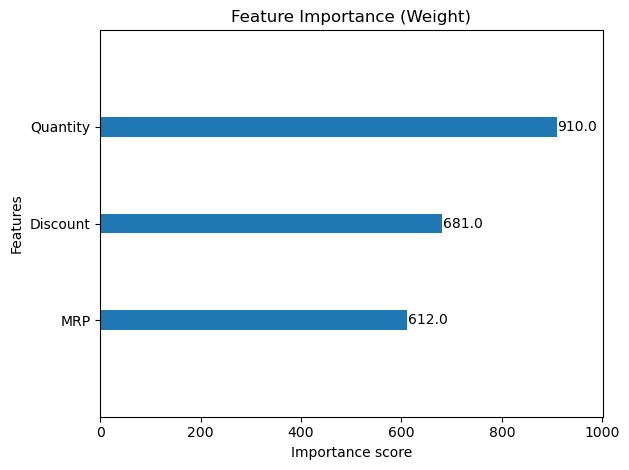

In [75]:
xgb.plot_importance(xgbmodel, importance_type='weight', title='Feature Importance (Weight)')
plt.tight_layout()
plt.grid(False)
plt.savefig('xgboost_feature_importance.png')

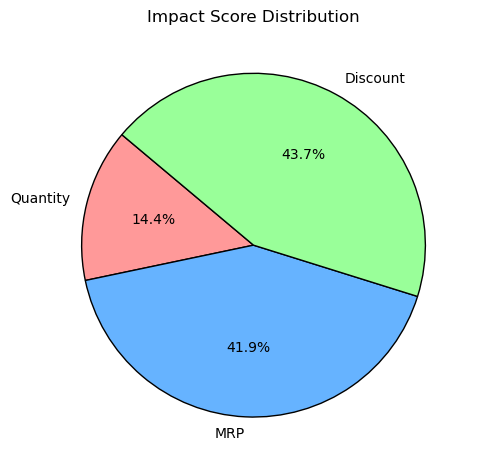

In [ ]:
plt.pie(
        importances, 
        labels=features, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#ff9999', '#66b3ff', '#99ff99'],
        wedgeprops={'edgecolor': 'black'}
    )
plt.title("Impact Score Distribution on rating count")
plt.tight_layout()